In [1]:
import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [2]:
from langchain_groq import ChatGroq

model = ChatGroq(model="openai/gpt-oss-120b")
model.invoke("What is AI")

AIMessage(content='**Artificial Intelligence (AI)** is a branch of computer science that focuses on creating machines and software capable of performing tasks that normally require human intelligence. These tasks can include learning, reasoning, problem‑solving, perception, language understanding, and even creativity.\n\n### Core Ideas\n\n| Concept | What It Means |\n|---------|---------------|\n| **Machine Learning (ML)** | Algorithms that improve their performance automatically as they are exposed to more data (e.g., spam filters, recommendation engines). |\n| **Deep Learning** | A subset of ML that uses multi‑layered neural networks to model complex patterns—think image recognition, speech‑to‑text, and language generation. |\n| **Natural Language Processing (NLP)** | Techniques that enable computers to understand, generate, and interact with human language (e.g., chatbots, translation tools). |\n| **Computer Vision** | Methods that let machines interpret visual information from phot

In [3]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results=5,
    topic="general"
)

tavily_search_tool.invoke("What is cricket")

{'query': 'What is cricket',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Cricket',
   'title': 'Cricket - Wikipedia',
   'content': '# Cricket. Team sport played with a bat and ball. **Cricket** is a bat-and-ball game that is played between two teams of eleven players on a field, at the centre of which is a 22-yard (20-metre; 66-foot) pitch with a wicket at each end, each comprising two bails "Bail (cricket)") (small sticks) balanced on three stumps "Stump (cricket)"). Two players from the batting "Batting (cricket)") team, the striker and nonstriker, stand in front of either wicket holding bats, while one player from the fielding "Fielding (cricket)") team, the bowler, bowls "Bowling (cricket)") the ball toward the striker\'s wicket from the opposite end of the pitch. Dismissal can occur in various ways, including being bowled (when the ball hits the striker\'s wicket and dislodges the bails), and by the fielding si

In [4]:
from langchain.tools import tool

@tool
def calc(expression:str)->str:
    """ Evaluate Mathematical expressions """
    return str(eval(expression))

In [5]:
from langchain.agents import create_agent

agent = create_agent(
    model = model,
    tools=[tavily_search_tool,calc]
)

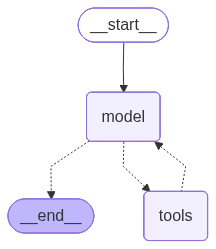

In [6]:
agent

In [7]:
user_input = "Who is the CEO of TensorGo, Hyderabad and then calculate 15+25"

for step in agent.stream(
    {"messages":user_input},
    stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Who is the CEO of TensorGo, Hyderabad and then calculate 15+25
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_8716bb6e-36bb-4bbc-88f8-97623b89cb76)
 Call ID: fc_8716bb6e-36bb-4bbc-88f8-97623b89cb76
  Args:
    query: TensorGo Hyderabad CEO
    search_depth: basic
    time_range: None
================================= Tool Message =================================
Name: tavily_search

{"query": "TensorGo Hyderabad CEO", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.f6s.com/company/tensorgo", "title": "TensorGo", "content": "TensorGo founders & employees. Srinivas Chilukuri | F6S - Images · Srinivas Chilukuri. Hyderabad, India ... About TensorGo - F6S Profile CEO @TensorGo. About", "score": 0.8351749, "raw_content": null}, {"url": "https://www.youtube.com/watch?v=N0Lsg_JHDow", "title": "Future of 

In [10]:
agent.invoke({"messages":"What is AI"})['messages'][-1].content

'**Artificial Intelligence (AI)** is a branch of computer science that aims to create systems capable of performing tasks that normally require human intelligence. These tasks include learning, reasoning, problem‑solving, perception, language understanding, and even creativity. In practice, AI systems use algorithms, data, and computational power to mimic, augment, or extend human cognitive abilities.\n\n---\n\n## Core Concepts\n\n| Concept | What It Means | Typical Techniques |\n|---------|---------------|---------------------|\n| **Machine Learning (ML)** | Algorithms that improve performance automatically through experience (data). | Supervised/unsupervised learning, reinforcement learning, deep learning. |\n| **Neural Networks** | Computational models inspired by the brain’s interconnected neurons. | Feed‑forward nets, convolutional nets (CNNs), recurrent nets (RNNs), transformers. |\n| **Reasoning & Knowledge Representation** | Structuring information so a system can draw logical 